In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("C:/Users/ELCOT/Downloads/Nassau Candy Distributor.csv")
print(df.head())
print(df.info())
print(df.shape)

   Row ID                      Order ID  Order Date   Ship Date  \
0       1  US-2021-103800-CHO-MIL-31000  03-01-2024  30-06-2026   
1       2  US-2021-112326-CHO-TRI-54000  04-01-2024  01-07-2026   
2       3  US-2021-112326-CHO-NUT-13000  04-01-2024  01-07-2026   
3       4  US-2021-112326-CHO-SCR-58000  04-01-2024  01-07-2026   
4       5  US-2021-141817-CHO-TRI-54000  05-01-2024  05-07-2026   

        Ship Mode  Customer ID Country/Region          City State/Province  \
0  Standard Class       103800  United States       Houston          Texas   
1  Standard Class       112326  United States    Naperville       Illinois   
2  Standard Class       112326  United States    Naperville       Illinois   
3  Standard Class       112326  United States    Naperville       Illinois   
4  Standard Class       141817  United States  Philadelphia   Pennsylvania   

  Postal Code   Division    Region     Product ID  \
0       77095  Chocolate  Interior  CHO-MIL-31000   
1       60540  Chocola

In [3]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64


In [4]:
df.drop_duplicates(inplace=True)

print("Duplicates removed")

Duplicates removed


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [7]:
print(df[df['Order Date'].isnull()])
print(df[df['Ship Date'].isnull()])

Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Country/Region, City, State/Province, Postal Code, Division, Region, Product ID, Product Name, Sales, Units, Gross Profit, Cost]
Index: []
Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Country/Region, City, State/Province, Postal Code, Division, Region, Product ID, Product Name, Sales, Units, Gross Profit, Cost]
Index: []


In [8]:
invalid_sales = df[df['Sales'] <= 0]
invalid_cost = df[df['Cost'] < 0]

print(invalid_sales.shape)
print(invalid_cost.shape)

(0, 18)
(0, 18)


In [9]:
df = df[df['Sales'] > 0]
df = df[df['Cost'] >= 0]

In [10]:
df['Units'] = df['Units'].fillna(df['Units'].median())

In [11]:
df['Division'] = df['Division'].str.strip()
df['Product Name'] = df['Product Name'].str.strip()

In [12]:
df['Shipping Delay'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

In [13]:
print(df.describe())
print(df.isnull().sum())

             Row ID                  Order Date                   Ship Date  \
count  10194.000000                       10194                       10194   
mean    5097.500000  2025-03-13 03:08:26.415538  2028-10-23 23:20:43.790465   
min        1.000000         2024-01-02 00:00:00         2026-06-30 00:00:00   
25%     2549.250000         2024-09-28 00:00:00         2027-11-09 00:00:00   
50%     5097.500000         2025-04-06 12:00:00         2028-12-18 00:00:00   
75%     7645.750000         2025-09-16 00:00:00         2029-11-08 00:00:00   
max    10194.000000         2025-12-31 00:00:00         2030-06-28 00:00:00   
std     2942.898656                         NaN                         NaN   

         Customer ID         Sales         Units  Gross Profit          Cost  \
count   10194.000000  10194.000000  10194.000000  10194.000000  10194.000000   
mean   134468.961154     13.908537      3.791838      9.166451      4.742087   
min    100006.000000      1.250000      1.000000

In [14]:
df['Gross Margin %'] = (
    df['Gross Profit'] / df['Sales']
) * 100

In [15]:
df['Profit per Unit'] = (
    df['Gross Profit'] / df['Units']
)

In [16]:
total_sales = df['Sales'].sum()

df['Revenue Contribution %'] = (
    df['Sales'] / total_sales
) * 100

In [17]:
total_profit = df['Gross Profit'].sum()

df['Profit Contribution %'] = (
    df['Gross Profit'] / total_profit
) * 100

In [18]:
df['Shipping Delay'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

In [19]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()

In [20]:
print(df.head())

   Row ID                      Order ID Order Date  Ship Date       Ship Mode  \
0       1  US-2021-103800-CHO-MIL-31000 2024-01-03 2026-06-30  Standard Class   
1       2  US-2021-112326-CHO-TRI-54000 2024-01-04 2026-07-01  Standard Class   
2       3  US-2021-112326-CHO-NUT-13000 2024-01-04 2026-07-01  Standard Class   
3       4  US-2021-112326-CHO-SCR-58000 2024-01-04 2026-07-01  Standard Class   
4       5  US-2021-141817-CHO-TRI-54000 2024-01-05 2026-07-05  Standard Class   

   Customer ID Country/Region          City State/Province Postal Code  ...  \
0       103800  United States       Houston          Texas       77095  ...   
1       112326  United States    Naperville       Illinois       60540  ...   
2       112326  United States    Naperville       Illinois       60540  ...   
3       112326  United States    Naperville       Illinois       60540  ...   
4       141817  United States  Philadelphia   Pennsylvania       19143  ...   

  Units Gross Profit  Cost Shipping De

In [21]:
df['Ship Date'] = df['Ship Date'].apply(
    lambda x: x.replace(year=2024)
)

In [22]:
df['Shipping Delay'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

In [23]:
print(df[['Order Date', 'Ship Date', 'Shipping Delay']].head())

  Order Date  Ship Date  Shipping Delay
0 2024-01-03 2024-06-30             179
1 2024-01-04 2024-07-01             179
2 2024-01-04 2024-07-01             179
3 2024-01-04 2024-07-01             179
4 2024-01-05 2024-07-05             182


In [24]:
top_profit_products = (
    df.groupby('Product Name')['Gross Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_profit_products)

Product Name
Wonka Bar -Scrumdiddlyumptious       19357.50
Wonka Bar - Triple Dazzle Caramel    18610.20
Wonka Bar - Milk Chocolate           17443.37
Wonka Bar - Nutty Crunch Surprise    16819.95
Wonka Bar - Fudge Mallows            16593.60
Lickable Wallpaper                    3930.00
Wonka Gum                              310.70
Everlasting Gobstopper                 104.00
Kazookles                               92.75
Hair Toffee                             59.50
Name: Gross Profit, dtype: float64


In [25]:
top_sales_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_sales_products)

Product Name
Wonka Bar - Triple Dazzle Caramel    28485.00
Wonka Bar -Scrumdiddlyumptious       27874.80
Wonka Bar - Milk Chocolate           26867.75
Wonka Bar - Fudge Mallows            24890.40
Wonka Bar - Nutty Crunch Surprise    23574.95
Lickable Wallpaper                    7860.00
Kazookles                             1205.75
Wonka Gum                              597.50
Everlasting Gobstopper                 130.00
Fizzy Lifting Drinks                    78.75
Name: Sales, dtype: float64


In [26]:
low_margin_products = (
    df.groupby('Product Name')['Gross Margin %']
    .mean()
    .sort_values()
    .head(10)
)

print(low_margin_products)

Product Name
Kazookles                             7.692308
Fun Dip                              40.000000
Nerds                                46.666667
SweeTARTS                            46.666667
Lickable Wallpaper                   50.000000
Wonka Gum                            52.000000
Fizzy Lifting Drinks                 60.000000
Laffy Taffy                          62.311558
Wonka Bar - Milk Chocolate           64.923077
Wonka Bar - Triple Dazzle Caramel    65.333333
Name: Gross Margin %, dtype: float64


In [27]:
division_analysis = (
    df.groupby('Division')[['Sales', 'Gross Profit']]
    .sum()
)

division_analysis['Average Margin %'] = (
    division_analysis['Gross Profit']
    / division_analysis['Sales']
) * 100

print(division_analysis)

               Sales  Gross Profit  Average Margin %
Division                                            
Chocolate  131692.90      88824.62         67.448298
Other        9663.25       4333.45         44.844643
Sugar         427.48        284.73         66.606625


In [28]:
division_analysis['Profit-to-Sales Ratio'] = (
    division_analysis['Gross Profit']
    / division_analysis['Sales']
)

print(division_analysis)

               Sales  Gross Profit  Average Margin %  Profit-to-Sales Ratio
Division                                                                   
Chocolate  131692.90      88824.62         67.448298               0.674483
Other        9663.25       4333.45         44.844643               0.448446
Sugar         427.48        284.73         66.606625               0.666066


In [29]:
pareto = (
    df.groupby('Product Name')['Gross Profit']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

pareto['Cumulative Profit'] = pareto['Gross Profit'].cumsum()

pareto['Cumulative %'] = (
    pareto['Cumulative Profit']
    / pareto['Gross Profit'].sum()
) * 100

print(pareto.head(15))

                         Product Name  Gross Profit  Cumulative Profit  \
0      Wonka Bar -Scrumdiddlyumptious      19357.50           19357.50   
1   Wonka Bar - Triple Dazzle Caramel      18610.20           37967.70   
2          Wonka Bar - Milk Chocolate      17443.37           55411.07   
3   Wonka Bar - Nutty Crunch Surprise      16819.95           72231.02   
4           Wonka Bar - Fudge Mallows      16593.60           88824.62   
5                  Lickable Wallpaper       3930.00           92754.62   
6                           Wonka Gum        310.70           93065.32   
7              Everlasting Gobstopper        104.00           93169.32   
8                           Kazookles         92.75           93262.07   
9                         Hair Toffee         59.50           93321.57   
10               Fizzy Lifting Drinks         47.25           93368.82   
11                        Laffy Taffy         33.48           93402.30   
12                          SweeTARTS 

In [30]:
print(df[['Sales', 'Cost', 'Gross Profit']].describe())

              Sales          Cost  Gross Profit
count  10194.000000  10194.000000  10194.000000
mean      13.908537      4.742087      9.166451
std       11.341020      5.061647      6.643740
min        1.250000      0.600000      0.250000
25%        7.200000      2.400000      4.900000
50%       10.800000      3.600000      7.470000
75%       18.000000      5.700000     12.250000
max      260.000000    130.000000    130.000000


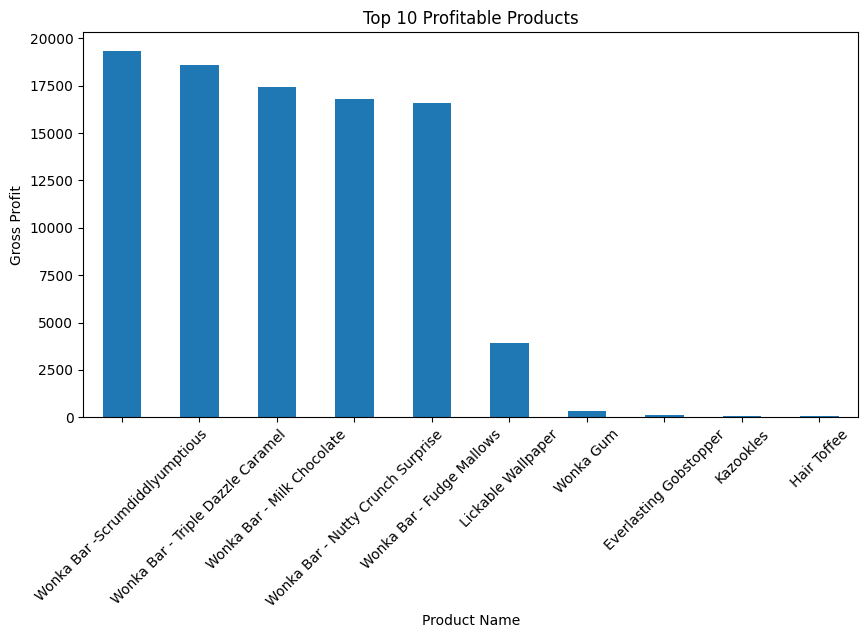

In [31]:
#data visualization

import matplotlib.pyplot as plt
import seaborn as sns

top_profit_products.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Profitable Products")
plt.ylabel("Gross Profit")
plt.xticks(rotation=45)

plt.show()

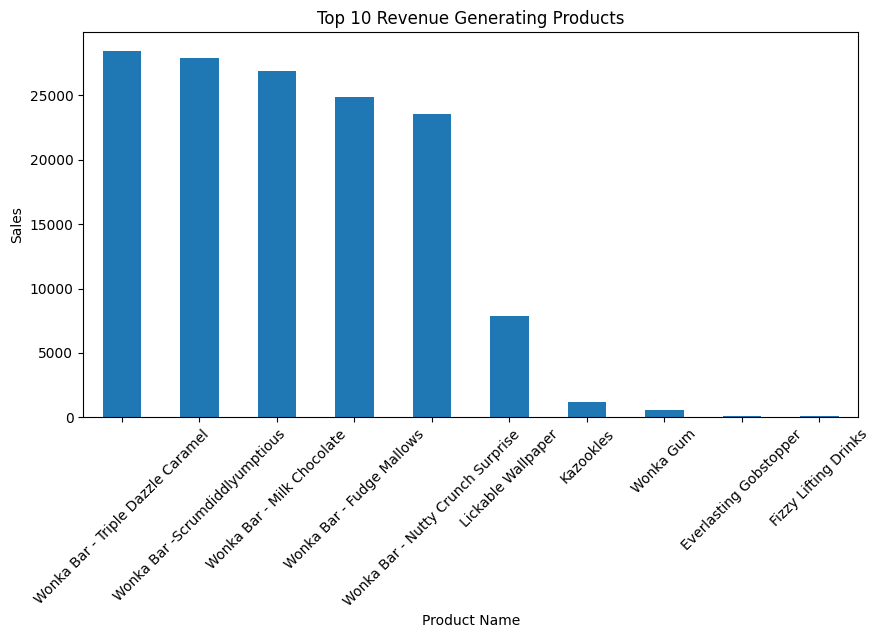

In [32]:
top_sales_products.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Revenue Generating Products")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

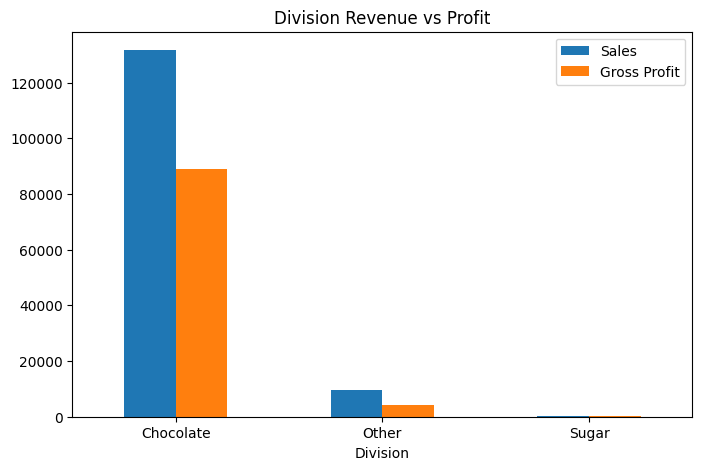

In [33]:
division_analysis[['Sales', 'Gross Profit']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Division Revenue vs Profit")
plt.xticks(rotation=0)

plt.show()

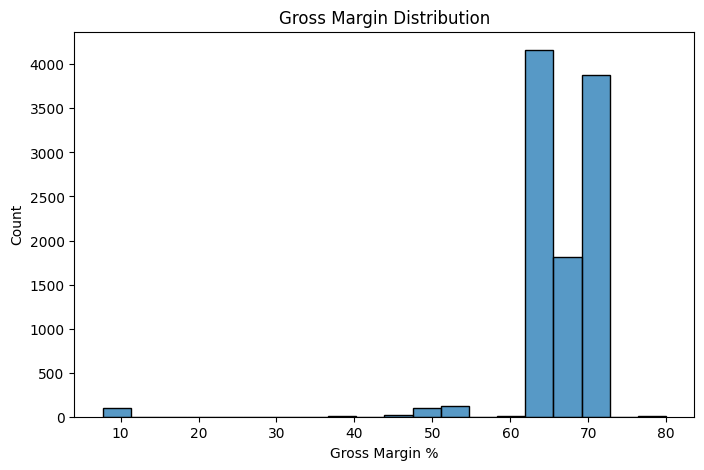

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(df['Gross Margin %'], bins=20)

plt.title("Gross Margin Distribution")

plt.show()

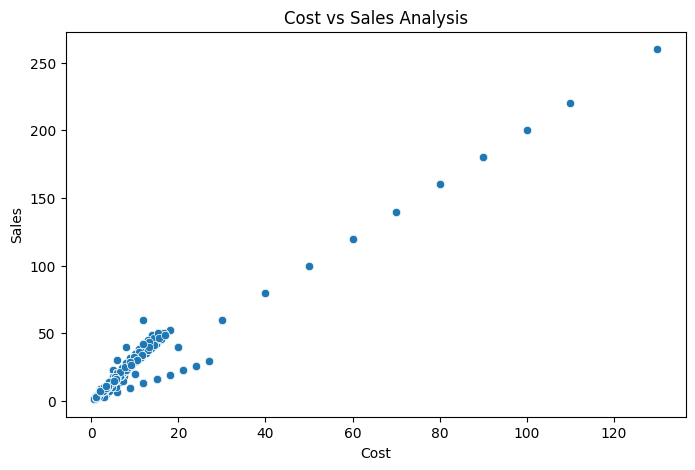

In [35]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Cost'],
    y=df['Sales']
)

plt.title("Cost vs Sales Analysis")

plt.show()

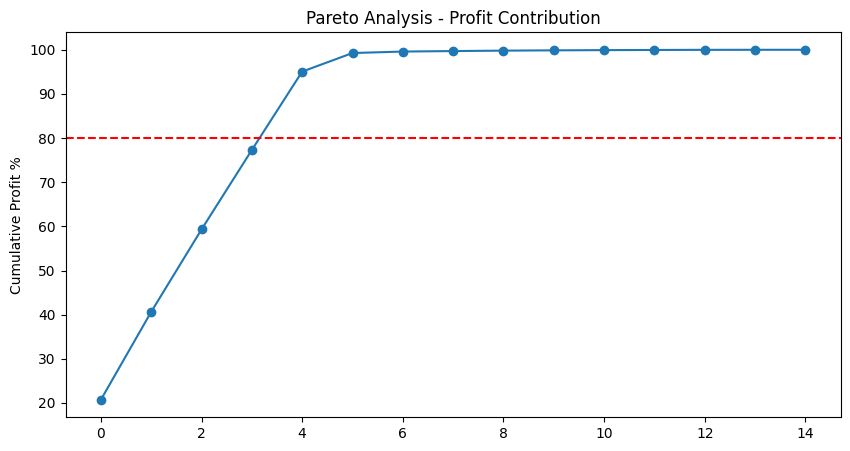

In [36]:
plt.figure(figsize=(10,5))

plt.plot(
    pareto['Cumulative %'],
    marker='o'
)

plt.axhline(
    y=80,
    color='r',
    linestyle='--'
)

plt.title("Pareto Analysis - Profit Contribution")
plt.ylabel("Cumulative Profit %")

plt.show()

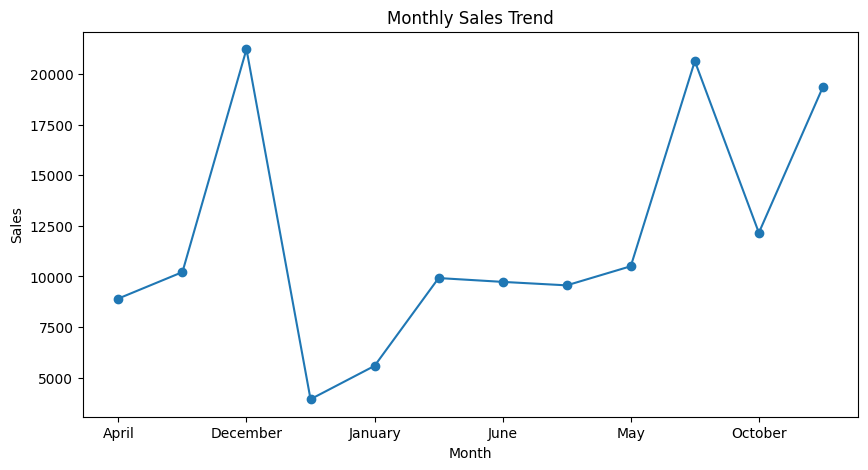

In [37]:
monthly_sales = (
    df.groupby('Month')['Sales']
    .sum()
)

monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")

plt.ylabel("Sales")

plt.show()

In [38]:
df.to_csv("cleaned_nassau_candy.csv", index=False)